โหลดข้อมูล

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('D3_student_placement_prediction_dataset_2026 (1).csv')

ดูโครงสร้าง

In [2]:
print(df.shape)
print(df.columns)
df.head()

(100000, 26)
Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


Clean ชื่อคอลัมน์

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

เช็ค target ก่อนทำอะไรต่อ

In [4]:
print(df['placement_status'].unique())

['Not Placed' 'Placed']


Clean target

In [5]:
df['placement_status'] = df['placement_status'].str.strip().str.lower()

ลบ Not Placed

In [6]:
df = df[df['placement_status'] != 'not placed']

ลบ column ที่ไม่จำเป็น

In [7]:
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

เช็คข้อมูลพื้นฐาน

In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 54459 entries, 2 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 54459 non-null  int64  
 1   age                        54459 non-null  int64  
 2   gender                     54459 non-null  object 
 3   cgpa                       54459 non-null  float64
 4   branch                     54459 non-null  object 
 5   college_tier               54459 non-null  object 
 6   internships_count          54459 non-null  int64  
 7   projects_count             54459 non-null  int64  
 8   certifications_count       54459 non-null  int64  
 9   coding_skill_score         54459 non-null  float64
 10  aptitude_score             54459 non-null  float64
 11  communication_skill_score  54459 non-null  float64
 12  logical_reasoning_score    54459 non-null  float64
 13  hackathons_participated    54459 non-null  int64  


,0
student_id,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0


จัดการ outlier

In [9]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

เช็คว่าข้อมูล

In [10]:
print(df.shape)
print(df.columns)
df.info()

(54459, 26)
Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 54459 entries, 2 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   student_id                 54459 non-null  float64
 1   age                        54459 non-null  float64
 2   gender                     54459 non-null  object 
 3   cgpa               

เช็คว่าเหลือแต่ “placed”

In [11]:
df['placement_status'].value_counts()

,count
placement_status,
placed,54459


แสดงข้อมูลที่สนใจ

In [12]:
# เลือกเฉพาะตัวแปรที่เราสนใจ
columns = [
    "aptitude_score",
    "coding_skill_score",
    "communication_skill_score",
    "logical_reasoning_score",
    "salary_package_lpa"
]

data = df[columns]

# ดูสถิติพื้นฐาน
stats = data.describe()

print(stats)

       aptitude_score  coding_skill_score  communication_skill_score  \
count    54459.000000        54459.000000               54459.000000   
mean        65.430050           70.520089                  68.383229   
std         14.803773           14.582796                  13.813979   
min         25.148399           30.187093                  30.564688   
25%         55.323007           60.530369                  58.981559   
50%         65.469800           70.732405                  68.440795   
75%         75.439412           80.759221                  77.926139   
max        100.000000          100.000000                 100.000000   

       logical_reasoning_score  salary_package_lpa  
count             54459.000000        54459.000000  
mean                 66.435818           13.316390  
std                  14.729822            1.583414  
min                  26.128065            8.990000  
25%                  56.417580           12.230000  
50%                  66.451542   

เรียงข้อมูล

In [13]:
summary = data.describe().T
print(summary)

                             count       mean        std        min  \
aptitude_score             54459.0  65.430050  14.803773  25.148399   
coding_skill_score         54459.0  70.520089  14.582796  30.187093   
communication_skill_score  54459.0  68.383229  13.813979  30.564688   
logical_reasoning_score    54459.0  66.435818  14.729822  26.128065   
salary_package_lpa         54459.0  13.316390   1.583414   8.990000   

                                 25%        50%        75%     max  
aptitude_score             55.323007  65.469800  75.439412  100.00  
coding_skill_score         60.530369  70.732405  80.759221  100.00  
communication_skill_score  58.981559  68.440795  77.926139  100.00  
logical_reasoning_score    56.417580  66.451542  76.610590  100.00  
salary_package_lpa         12.230000  13.300000  14.390000   17.63  


ดูสถิติพื้นฐานของตัวแปรอิสระ

In [14]:
df[['aptitude_score',
    'coding_skill_score',
    'communication_skill_score',
    'logical_reasoning_score']].describe()

,aptitude_score,coding_skill_score,communication_skill_score,logical_reasoning_score
count,54459.000000,54459.000000,54459.000000,54459.000000
mean,65.430050,70.520089,68.383229,66.435818
std,14.803773,14.582796,13.813979,14.729822
min,25.148399,30.187093,30.564688,26.128065
25%,55.323007,60.530369,58.981559,56.417580
50%,65.469800,70.732405,68.440795,66.451542
75%,75.439412,80.759221,77.926139,76.610590
max,100.000000,100.000000,100.000000,100.000000


เช็คความสัมพันธ์กับ salary

In [15]:
df[['aptitude_score',
    'coding_skill_score',
    'communication_skill_score',
    'logical_reasoning_score',
    'salary_package_lpa']].corr()['salary_package_lpa'].sort_values(ascending=False)

,salary_package_lpa
salary_package_lpa,1.000000
coding_skill_score,0.455205
communication_skill_score,-0.000011
logical_reasoning_score,-0.002972
aptitude_score,-0.002994


Distribution ของ Salary

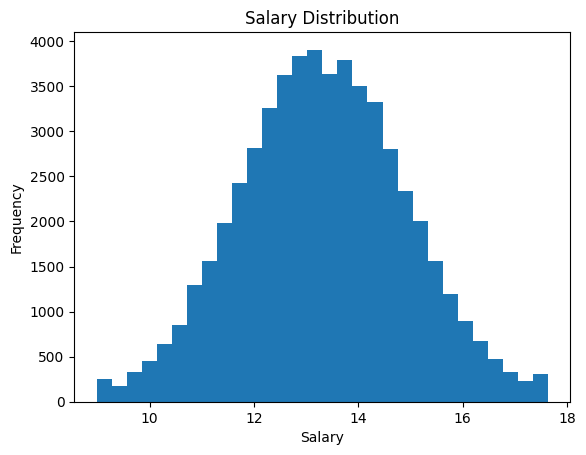

In [16]:
import matplotlib.pyplot as plt

plt.hist(df['salary_package_lpa'], bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

Boxplot (หา Outlier)

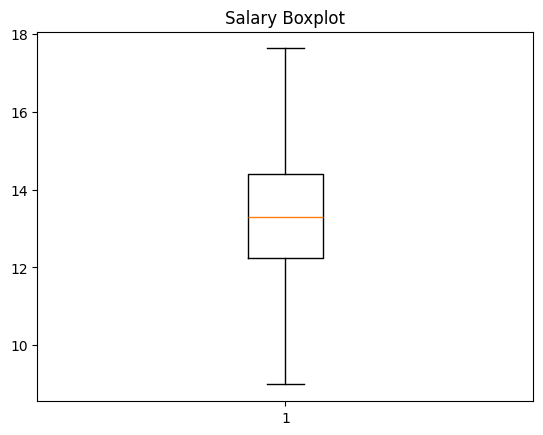

In [17]:
plt.boxplot(df['salary_package_lpa'])
plt.title('Salary Boxplot')
plt.show()

Scatter Plot

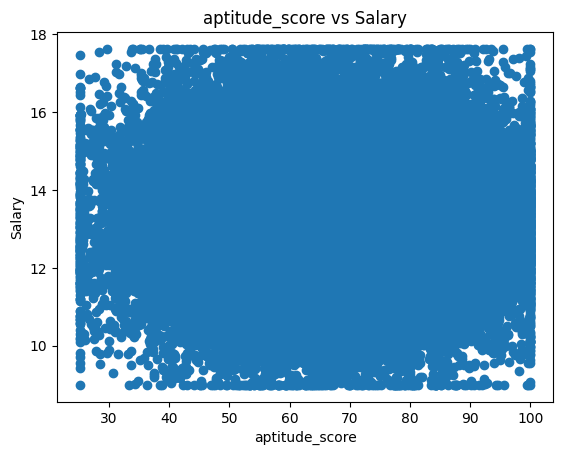

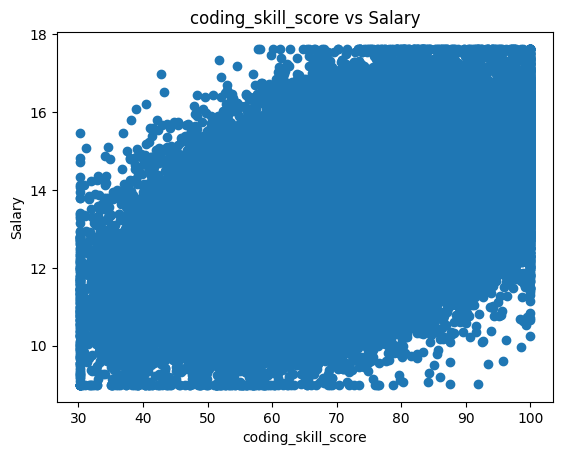

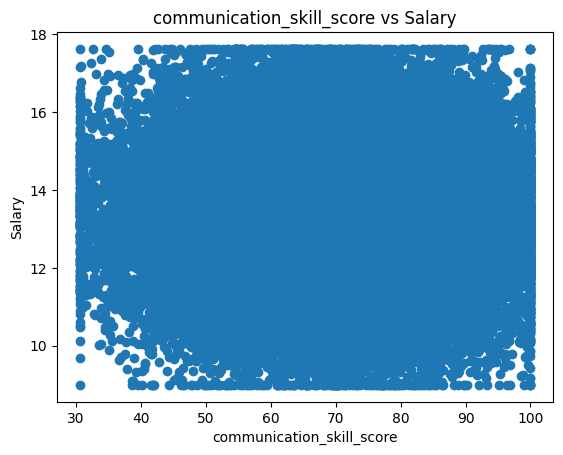

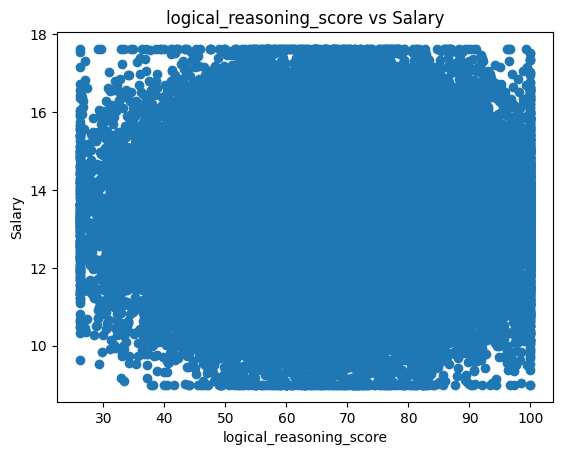

In [18]:
features = [
    'aptitude_score',
    'coding_skill_score',
    'communication_skill_score',
    'logical_reasoning_score'
]

for col in features:
    plt.scatter(df[col], df['salary_package_lpa'])
    plt.xlabel(col)
    plt.ylabel('Salary')
    plt.title(f'{col} vs Salary')
    plt.show()

เส้นแนวโน้ม

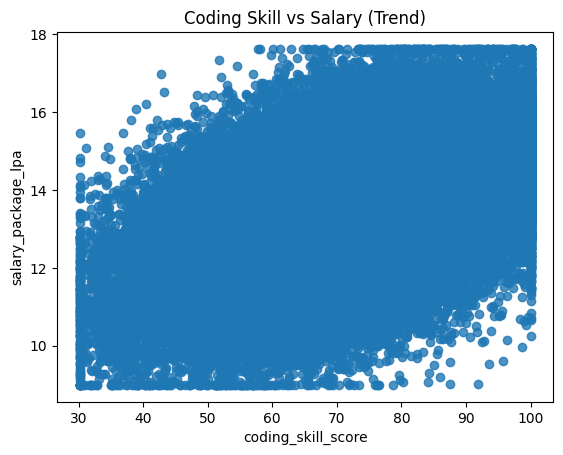

In [19]:
import seaborn as sns

sns.regplot(x='coding_skill_score', y='salary_package_lpa', data=df)
plt.title('Coding Skill vs Salary (Trend)')
plt.show()

Distribution ของ Feature

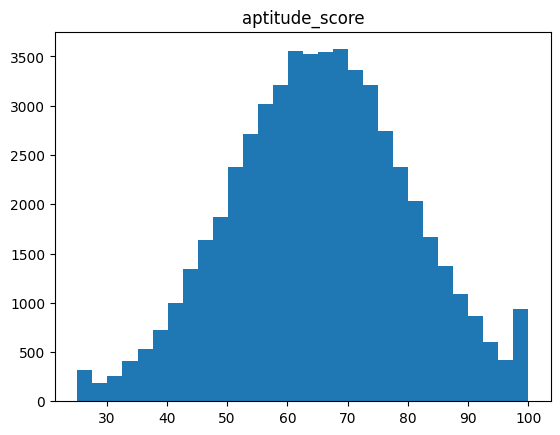

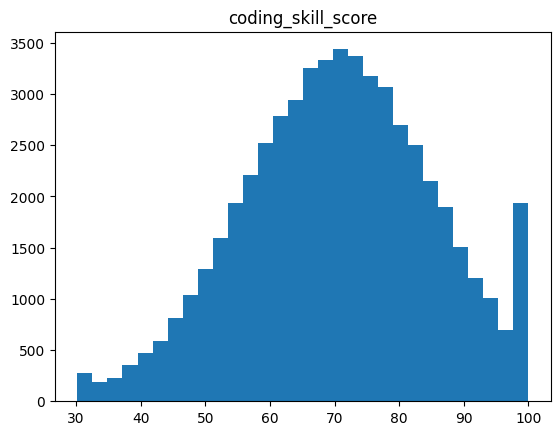

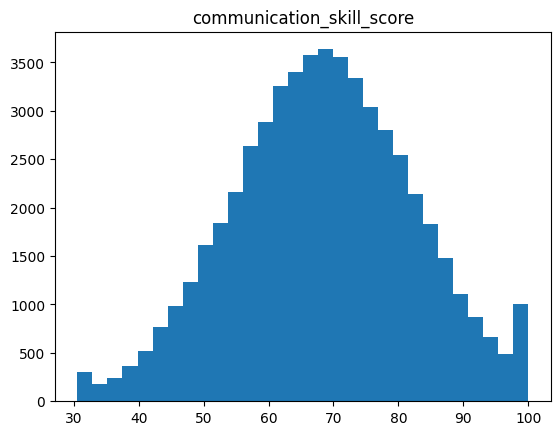

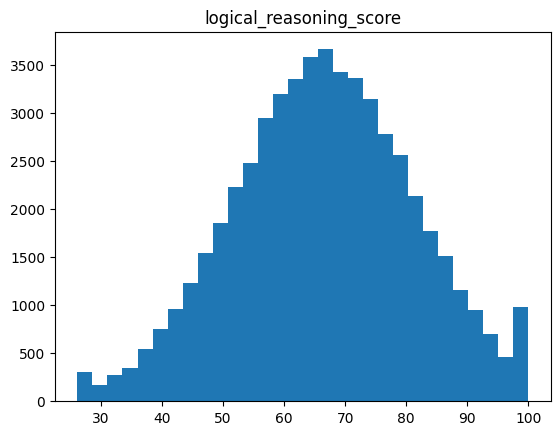

In [21]:
for col in features:
    plt.hist(df[col], bins=30)
    plt.title(col)
    plt.show()

Pairplot

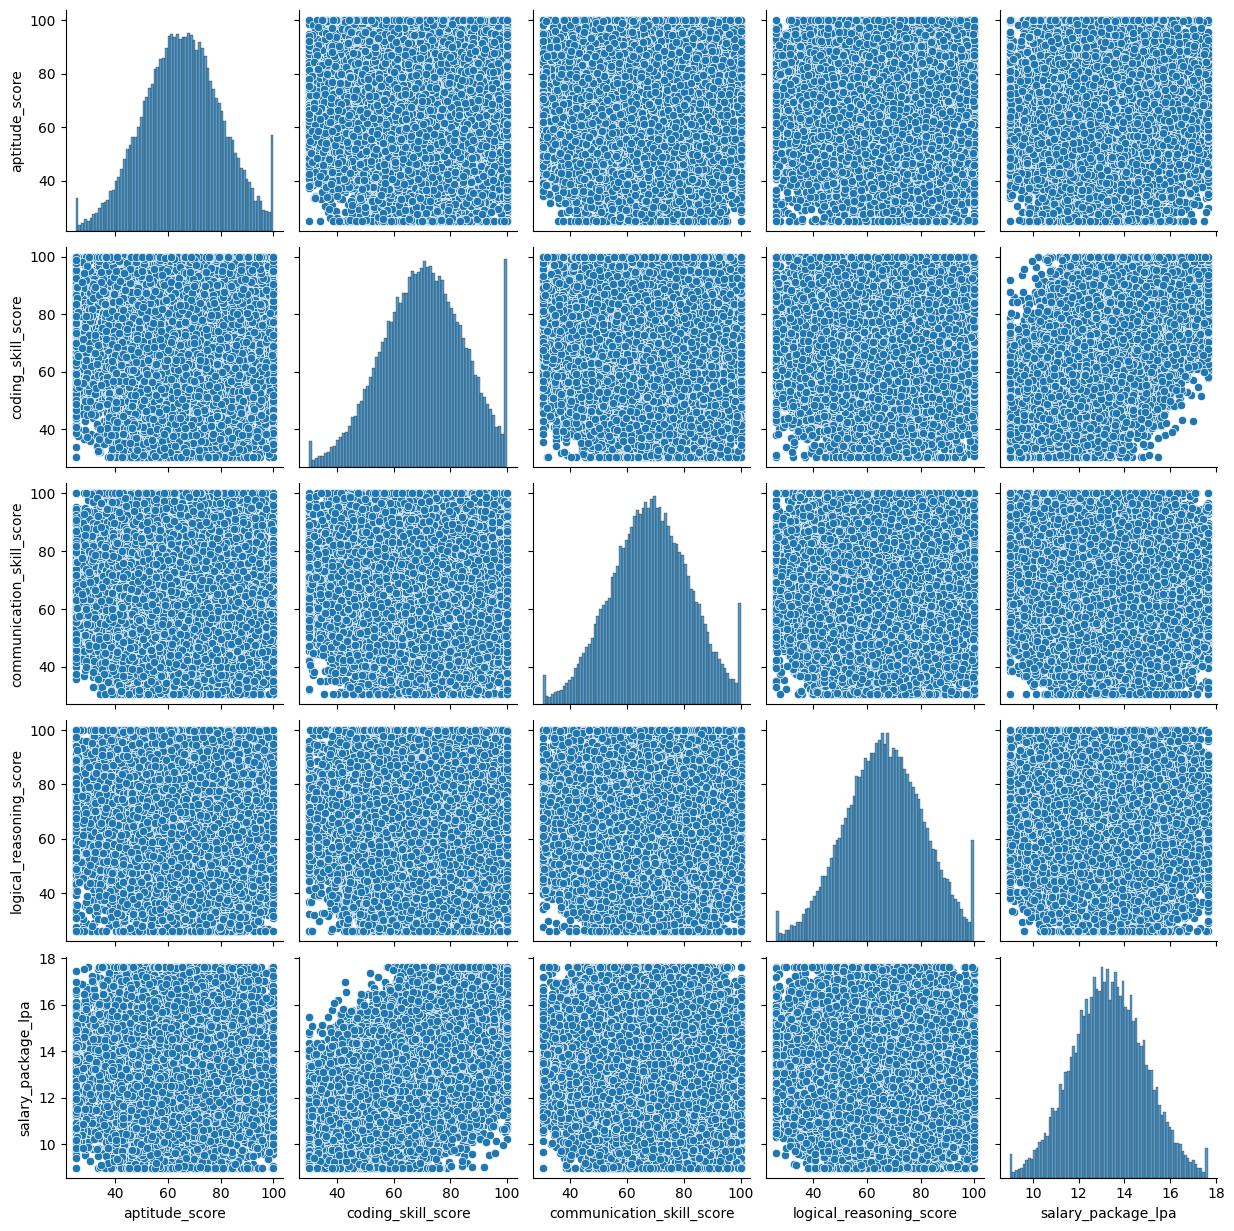

In [22]:
sns.pairplot(df[features + ['salary_package_lpa']])
plt.show()

Model

เตรียมข้อมูล
เลือก feature + target

In [23]:
features = [
    'aptitude_score',
    'coding_skill_score',
    'communication_skill_score',
    'logical_reasoning_score'
]

X = df[features]
y = df['salary_package_lpa']

train / test split

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

วัดผล

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 1.4085230293311193
Linear Regression R2: 0.20633470591519554


Random Forest

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 1.4576521973713936
Random Forest R2: 0.15000316475340292


เทียบผล

In [28]:
print("LR  -> RMSE:", rmse_lr, "| R2:", r2_lr)
print("RF  -> RMSE:", rmse_rf, "| R2:", r2_rf)

LR  -> RMSE: 1.4085230293311193 | R2: 0.20633470591519554
RF  -> RMSE: 1.4576521973713936 | R2: 0.15000316475340292


ดูว่า feature ไหนสำคัญ

In [29]:
import pandas as pd

pd.DataFrame({
    'feature': features,
    'coefficient': lr.coef_
})

,feature,coefficient
0,aptitude_score,-0.000395
1,coding_skill_score,0.049417
2,communication_skill_score,-0.000455
3,logical_reasoning_score,-0.000340


Random Forest

In [30]:
pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

,0
coding_skill_score,0.404518
logical_reasoning_score,0.200052
aptitude_score,0.198128
communication_skill_score,0.197302


Visualization ผลลัพธ์

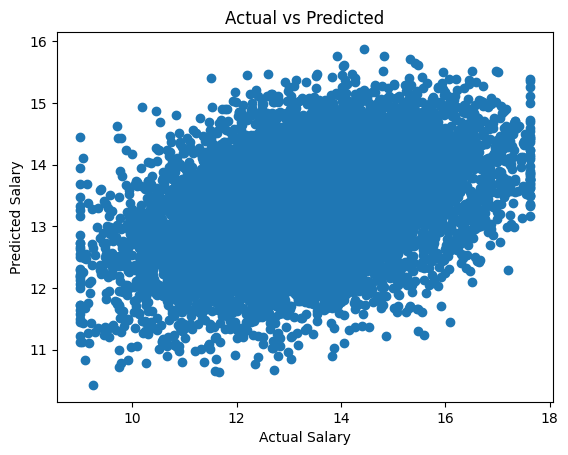

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

Export Model

In [32]:
import joblib
from sklearn.linear_model import LinearRegression

# train
model = LinearRegression()
model.fit(X, y)

# save
joblib.dump(model, 'salary_model.pkl')

['salary_model.pkl']